# Step 2 - EDA Walkthrough

This notebook is the teaching version of `src/02_eda.py`.

Audience:
- Readers who want to understand the project's visual story before moving into formal tests and forecasting.

Prerequisites:
- Basic comfort with pandas tables and simple matplotlib plots
- Familiarity with the cleaned annual dataset from preprocessing

Learning goals:
- Understand what each of the six EDA charts is trying to show
- Connect visual patterns to later modeling choices
- Save the same chart files as the pipeline script


## Outline

1. Set up imports, colors, and plotting defaults
2. Load the annual and country datasets
3. Build the six core EDA charts one by one
4. Review the saved chart files
5. Try a short interpretation exercise


In [1]:
from pathlib import Path
import os
import sys
import warnings
filterwarnings = True
if filterwarnings:
    import warnings
    warnings.filterwarnings("ignore")

candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
PROJECT_ROOT = next(path for path in candidates if (path / "config.py").exists())
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from config import ANNUAL_FILE, BREAK_YEAR, CHART_DIR, COUNTRY_FILE

warnings.filterwarnings(
    "ignore",
    message="FigureCanvasAgg is non-interactive.*",
    category=UserWarning,
)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.color": "#cccccc",
    "figure.dpi": 140,
    "savefig.dpi": 140,
    "savefig.bbox": "tight",
})

NAVY = "#0f2744"
BLUE = "#1d4ed8"
TEAL = "#0d9488"
AMBER = "#f59e0b"
RED = "#dc2626"
GREEN = "#16a34a"
GRAY = "#64748b"

PROJECT_ROOT


WindowsPath('C:/Users/Pegasus/Desktop/SemiTrack2')

## Load the datasets used in EDA

The annual dataset drives the time-series views, while the country breakdown dataset is needed for the supplier-evolution chart. It helps to confirm both tables before plotting.


In [2]:
ann = pd.read_csv(ANNUAL_FILE)
ann["year"] = ann["year"].astype(int)
ann = ann.sort_values("year").reset_index(drop=True)

cty = pd.read_csv(COUNTRY_FILE)
cty["year"] = cty["year"].astype(int)

pd.DataFrame(
    {
        "dataset": ["annual integrated", "country breakdown"],
        "rows": [ann.shape[0], cty.shape[0]],
        "columns": [ann.shape[1], cty.shape[1]],
        "years": [f"{ann['year'].min()}-{ann['year'].max()}", f"{cty['year'].min()}-{cty['year'].max()}"],
    }
)


,dataset,rows,columns,years
0,annual integrated,30,35,1995-2024
1,country breakdown,2253,11,1995-2024


## Preview the key annual fields

EDA is easier to follow when we keep the core yearly variables in view. These are the columns that show up most often in the charts below.


In [3]:
ann[
    [
        "year",
        "import_value_usd_billions",
        "real_value_2015usd_billions",
        "yoy_real_growth_pct",
        "china_share_pct",
        "supplier_hhi",
        "hs8542_share_pct",
        "hs3818_share_pct",
    ]
].tail(8)


,year,import_value_usd_billions,real_value_2015usd_billions,yoy_real_growth_pct,china_share_pct,supplier_hhi,hs8542_share_pct,hs3818_share_pct
22,2017,2.8829,2.6716,46.5600,27.6800,0.1179,93.0300,6.9700
23,2018,7.5613,6.7009,150.8300,33.2100,0.2101,98.1400,1.8600
24,2019,10.3379,8.7885,31.1500,35.5100,0.2194,98.6600,1.3400
25,2020,8.5111,7.0684,-19.5700,34.4800,0.1880,98.9500,1.0500
26,2021,12.5855,9.8664,39.5800,35.6900,0.2249,98.8800,1.1200
27,2022,16.5144,11.8095,19.6900,31.5500,0.1833,98.9000,1.1000
28,2023,19.0075,12.7337,7.8300,53.4500,0.3205,98.2600,1.7400
29,2024,23.0498,14.5977,14.6400,45.8300,0.2909,99.1800,0.8200


## Plot 1 - 30-year import trajectory

This stacked bar chart answers the biggest first question: how large did semiconductor imports become over time, and how did the HS 8542 and HS 3818 components contribute to that total?


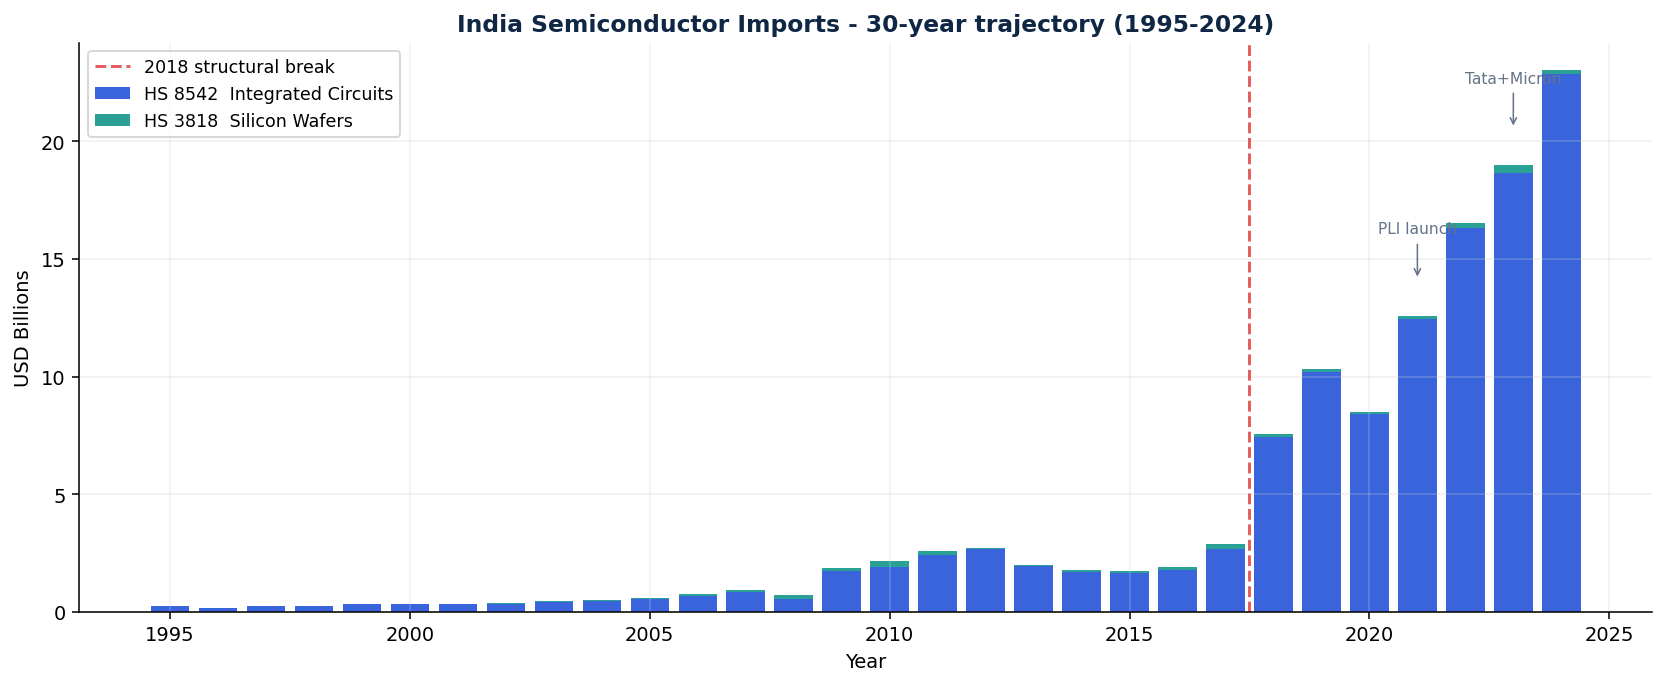

In [4]:
chart_01 = Path(CHART_DIR) / "eda_01_trajectory.png"
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(ann["year"], ann["hs8542_import_usd"] / 1e9, label="HS 8542  Integrated Circuits", color=BLUE, alpha=0.88)
ax.bar(
    ann["year"],
    ann["hs3818_import_usd"] / 1e9,
    bottom=ann["hs8542_import_usd"] / 1e9,
    label="HS 3818  Silicon Wafers",
    color=TEAL,
    alpha=0.88,
)
ax.axvline(x=BREAK_YEAR - 0.5, color=RED, linestyle="--", lw=1.5, label=f"{BREAK_YEAR} structural break", alpha=0.75)
ax.set_xlabel("Year")
ax.set_ylabel("USD Billions")
ax.set_title("India Semiconductor Imports - 30-year trajectory (1995-2024)", fontsize=12, fontweight="bold", color=NAVY)
ax.legend(fontsize=9)
for year, label in {2021: "PLI launch", 2023: "Tata+Micron"}.items():
    y_value = ann.loc[ann["year"] == year, "import_value_usd_billions"].values[0] + 1.5
    ax.annotate(label, (year, y_value), xytext=(year, y_value + 2), arrowprops=dict(arrowstyle="->", color=GRAY, lw=0.8), fontsize=8, color=GRAY, ha="center")
plt.tight_layout()
plt.savefig(chart_01)
plt.show()
plt.close(fig)


## Plot 2 - year-on-year real growth

The level chart is useful, but growth rates reveal volatility much more clearly. This figure makes the 2018 split easier to interpret because it compares growth behavior before and after the break.


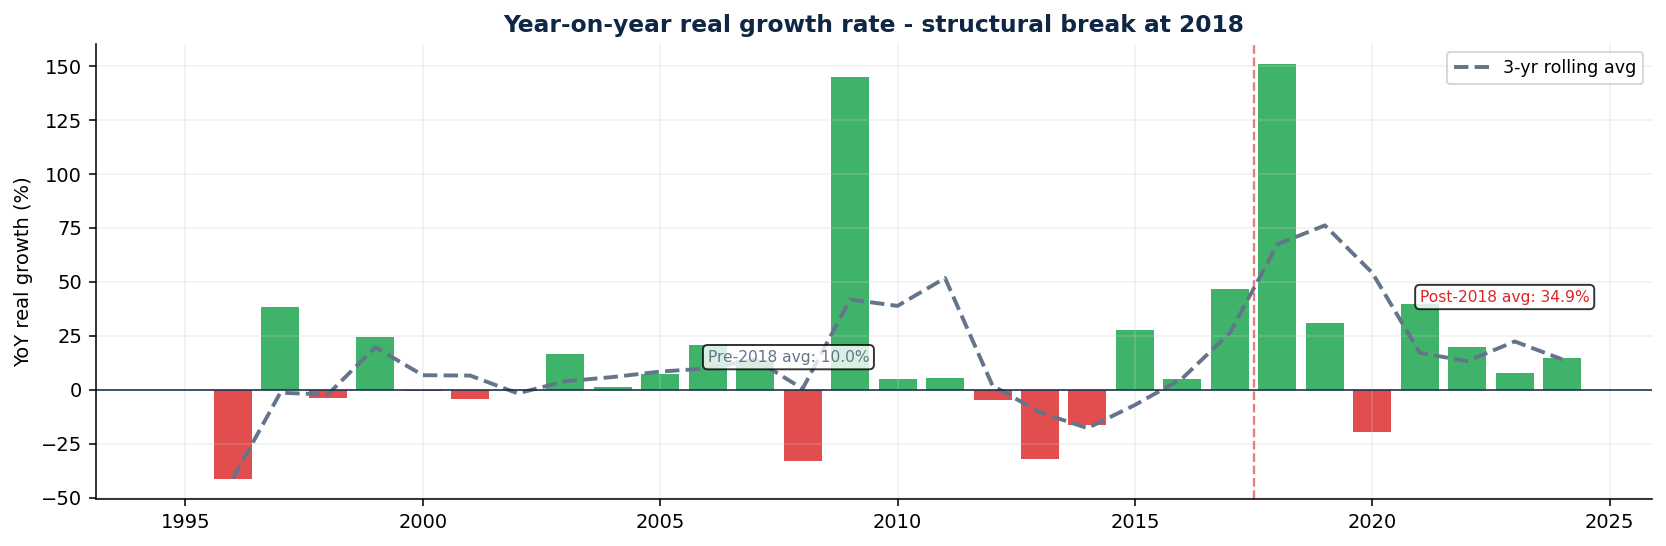

In [5]:
chart_02 = Path(CHART_DIR) / "eda_02_yoy_growth.png"
fig, ax = plt.subplots(figsize=(12, 4))
yoy = ann["yoy_real_growth_pct"].fillna(0)
bar_colors = [GREEN if value >= 0 else RED for value in yoy]
ax.bar(ann["year"], yoy, color=bar_colors, alpha=0.82)
rolling_growth = ann["yoy_real_growth_pct"].rolling(3, min_periods=1).mean()
ax.plot(ann["year"], rolling_growth, color=GRAY, lw=2, linestyle="--", label="3-yr rolling avg")
ax.axhline(0, color=NAVY, lw=0.8)
ax.axvline(x=BREAK_YEAR - 0.5, color=RED, linestyle="--", lw=1.2, alpha=0.6)
pre_avg = ann[ann["year"] < BREAK_YEAR]["yoy_real_growth_pct"].mean()
post_avg = ann[ann["year"] >= BREAK_YEAR]["yoy_real_growth_pct"].mean()
ax.annotate(f"Pre-{BREAK_YEAR} avg: {pre_avg:.1f}%", (2006, pre_avg + 3), fontsize=8, color=GRAY, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
ax.annotate(f"Post-{BREAK_YEAR} avg: {post_avg:.1f}%", (2021, post_avg + 6), fontsize=8, color=RED, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
ax.set_ylabel("YoY real growth (%)")
ax.set_title("Year-on-year real growth rate - structural break at 2018", fontsize=12, fontweight="bold", color=NAVY)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(chart_02)
plt.show()
plt.close(fig)


Imports didn’t just increase — the rate of increase became faster after 2018.

## Plot 3 - China share and supplier concentration

This dual-axis chart connects two related ideas: dependency on one supplier country and overall concentration across suppliers. The two lines are not the same concept, so seeing them together is informative.


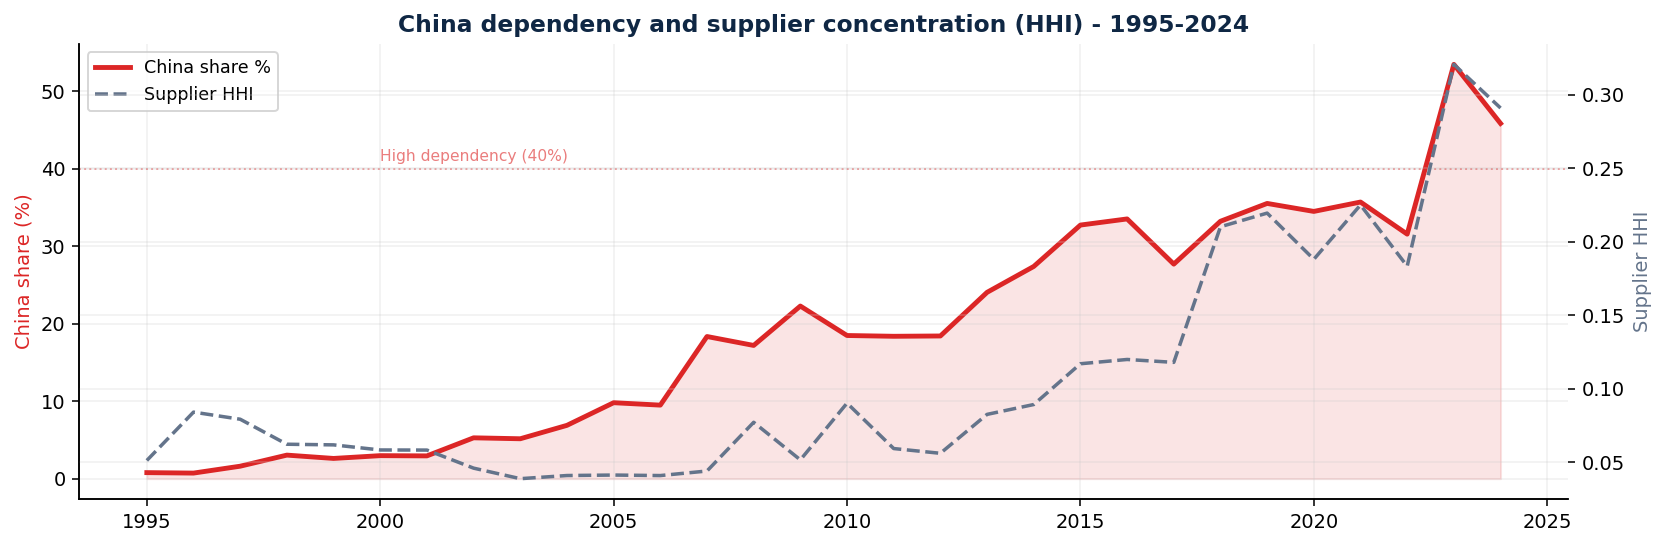

In [6]:
chart_03 = Path(CHART_DIR) / "eda_03_china_hhi.png"
fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()
ax1.fill_between(ann["year"], ann["china_share_pct"], color=RED, alpha=0.12, label="_nolegend_")
ax1.plot(ann["year"], ann["china_share_pct"], color=RED, lw=2.5, label="China share %")
ax2.plot(ann["year"], ann["supplier_hhi"], color=GRAY, lw=1.8, linestyle="--", label="Supplier HHI")
ax1.axhline(40, color=RED, linestyle=":", lw=1, alpha=0.4)
ax1.annotate("High dependency (40%)", (2000, 41), fontsize=8, color=RED, alpha=0.6)
ax1.set_ylabel("China share (%)", color=RED)
ax2.set_ylabel("Supplier HHI", color=GRAY)
ax1.set_title("China dependency and supplier concentration (HHI) - 1995-2024", fontsize=12, fontweight="bold", color=NAVY)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
plt.tight_layout()
plt.savefig(chart_03)
plt.show()
plt.close(fig)


India’s semiconductor imports became increasingly dependent on China AND less diversified — especially after 2018.


## Plot 4 - HS composition over time and in 2024

The left panel shows how the HS code mix evolves over time, while the right panel answers a simpler snapshot question: what did the import basket look like in the latest year?


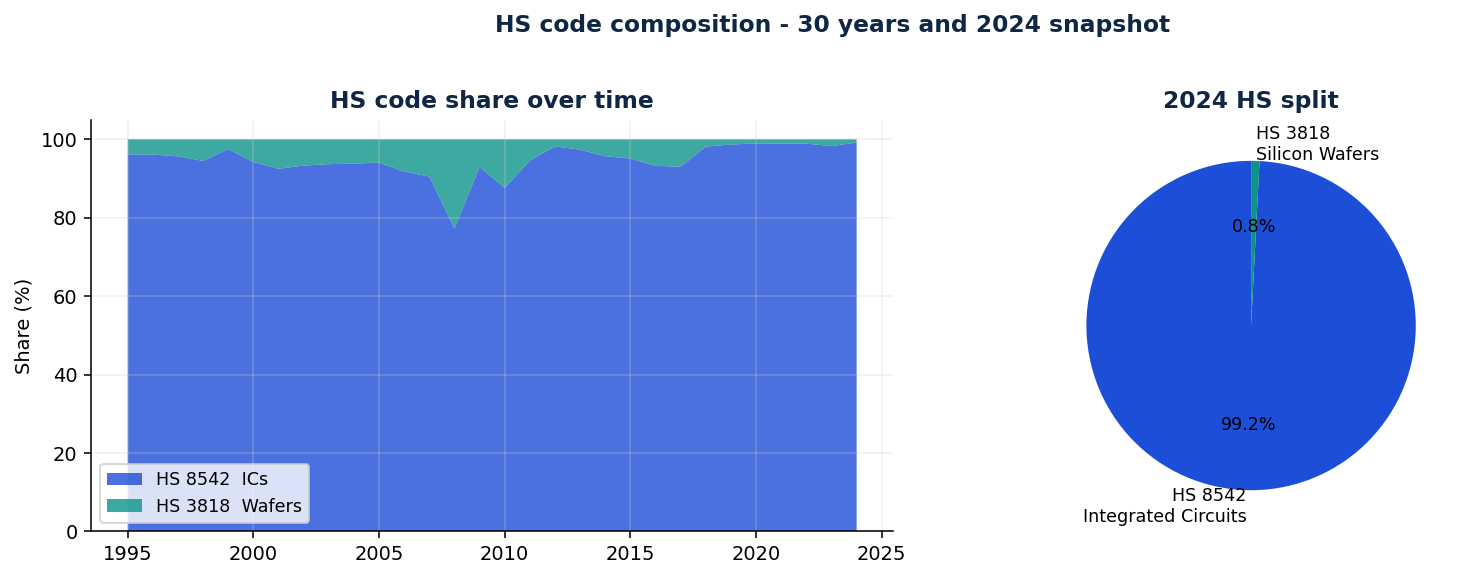

In [7]:
chart_04 = Path(CHART_DIR) / "eda_04_hs_split.png"
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.stackplot(ann["year"], ann["hs8542_share_pct"], ann["hs3818_share_pct"], labels=["HS 8542  ICs", "HS 3818  Wafers"], colors=[BLUE, TEAL], alpha=0.80)
ax1.set_ylabel("Share (%)")
ax1.set_title("HS code share over time", fontweight="bold", color=NAVY)
ax1.legend(fontsize=9, loc="lower left")

latest = ann.iloc[-1]
ax2.pie(
    [latest["hs8542_import_usd"], latest["hs3818_import_usd"]],
    labels=["HS 8542\nIntegrated Circuits", "HS 3818\nSilicon Wafers"],
    colors=[BLUE, TEAL],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 9},
)
ax2.set_title("2024 HS split", fontweight="bold", color=NAVY)
plt.suptitle("HS code composition - 30 years and 2024 snapshot", fontsize=12, fontweight="bold", color=NAVY, y=1.02)
plt.tight_layout()
plt.savefig(chart_04)
plt.show()
plt.close(fig)


The temporary shift around 2008–2010 reflects the impact of the global financial crisis, which reduced international demand and disrupted trade flows, leading to a short-term change in India’s semiconductor import composition.


## Plot 5 - supplier evolution by decade

A single line cannot easily show how the top exporters changed across long time spans. Breaking the view into decade snapshots gives a compact answer to who dominated in each period.


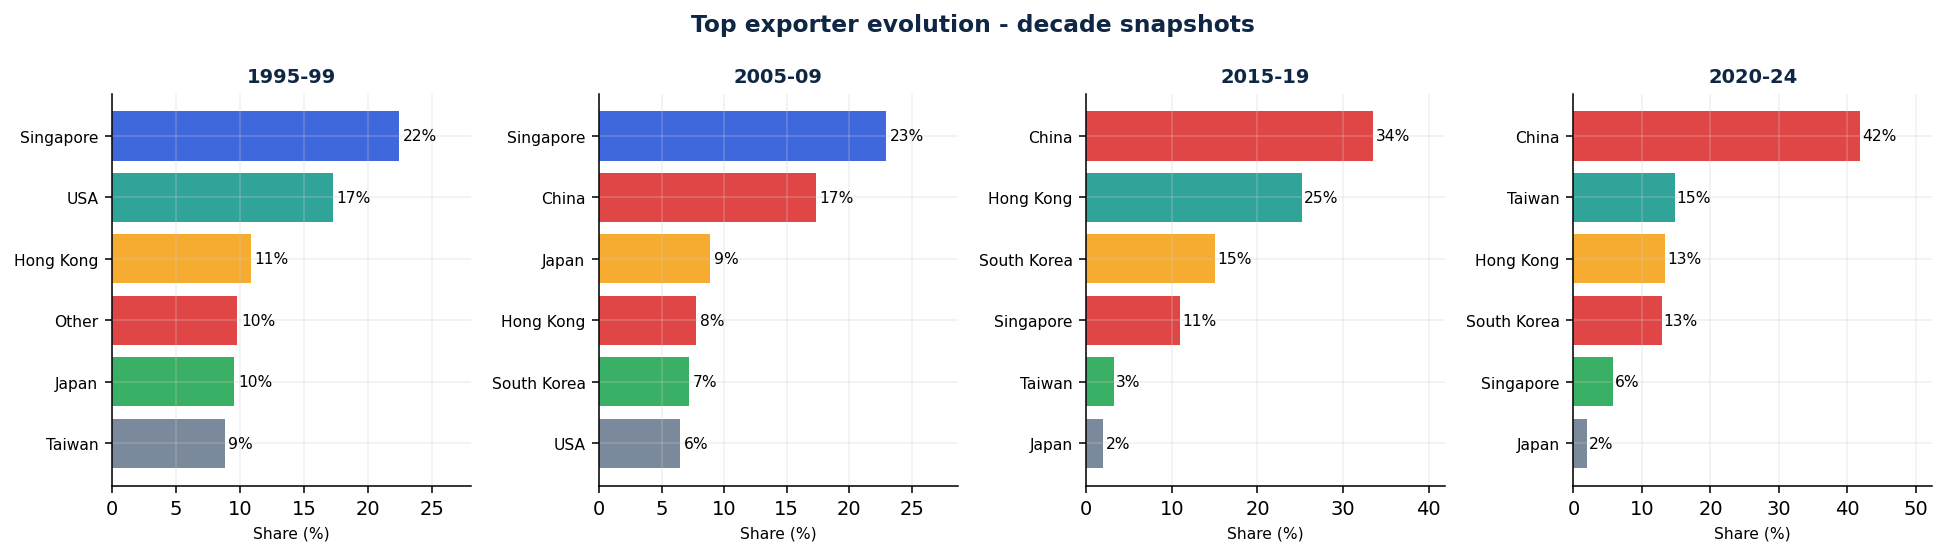

In [8]:
chart_05 = Path(CHART_DIR) / "eda_05_supplier_evolution.png"
decades = [(1995, 1999), (2005, 2009), (2015, 2019), (2020, 2024)]
decade_labels = ["1995-99", "2005-09", "2015-19", "2020-24"]
palette = [BLUE, TEAL, AMBER, RED, GREEN, GRAY, "#7c3aed", "#d97706", "#0369a1", "#15803d"]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (start_year, end_year), label in zip(axes, decades, decade_labels):
    subset = cty[(cty["year"] >= start_year) & (cty["year"] <= end_year)]
    grouped = subset.groupby("exporter_name")["import_value_usd"].sum().reset_index()
    grouped["share"] = grouped["import_value_usd"] / grouped["import_value_usd"].sum() * 100
    top = grouped.nlargest(6, "share")
    bar_colors = [RED if name == "China" else palette[idx % len(palette)] for idx, name in enumerate(top["exporter_name"])]
    bars = ax.barh(top["exporter_name"][::-1], top["share"][::-1], color=bar_colors[::-1], alpha=0.85)
    for bar, value in zip(bars, top["share"][::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2, f"{value:.0f}%", va="center", fontsize=8)
    ax.set_title(label, fontweight="bold", color=NAVY, fontsize=10)
    ax.set_xlabel("Share (%)", fontsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xlim(0, grouped["share"].max() * 1.25)
plt.suptitle("Top exporter evolution - decade snapshots", fontsize=12, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.savefig(chart_05)
plt.show()
plt.close(fig)


## Plot 6 - correlation heatmap

The final chart summarizes which annual variables tend to move together. Correlation does not prove causation, but it is a fast way to spot relationships worth thinking about before modeling.


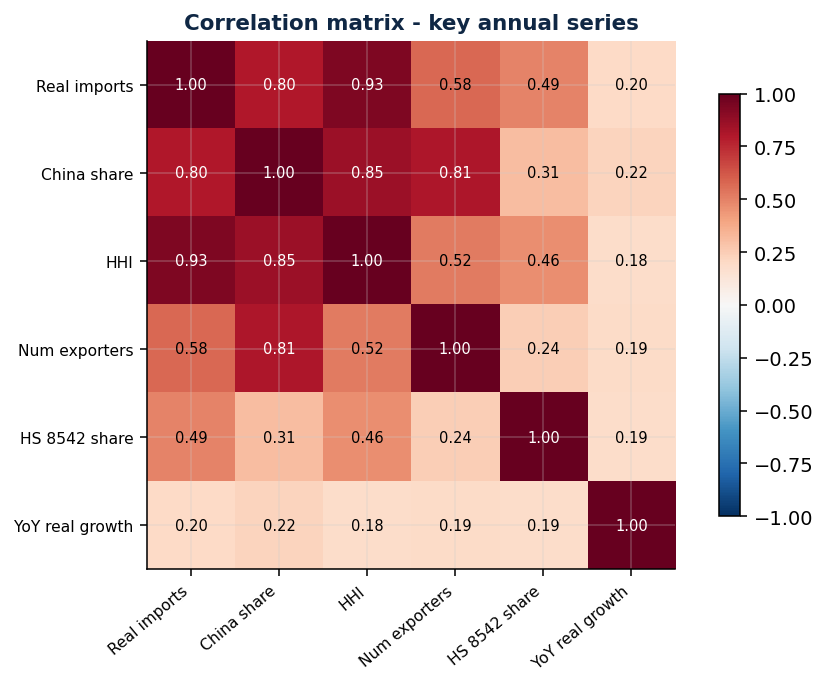

,real_value_2015usd_billions,china_share_pct,supplier_hhi,num_exporting_countries,hs8542_share_pct,yoy_real_growth_pct
real_value_2015usd_billions,1.0000,0.8041,0.9335,0.5774,0.4940,0.1960
china_share_pct,0.8041,1.0000,0.8531,0.8083,0.3104,0.2237
supplier_hhi,0.9335,0.8531,1.0000,0.5220,0.4648,0.1842
num_exporting_countries,0.5774,0.8083,0.5220,1.0000,0.2444,0.1929
hs8542_share_pct,0.4940,0.3104,0.4648,0.2444,1.0000,0.1851
yoy_real_growth_pct,0.1960,0.2237,0.1842,0.1929,0.1851,1.0000


In [9]:
chart_06 = Path(CHART_DIR) / "eda_06_correlation.png"
corr_cols = [
    "real_value_2015usd_billions",
    "china_share_pct",
    "supplier_hhi",
    "num_exporting_countries",
    "hs8542_share_pct",
    "yoy_real_growth_pct",
]
corr_labels = ["Real imports", "China share", "HHI", "Num exporters", "HS 8542 share", "YoY real growth"]
corr = ann[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr.values, cmap=plt.cm.RdBu_r, vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(corr_labels)))
ax.set_yticks(range(len(corr_labels)))
ax.set_xticklabels(corr_labels, rotation=40, ha="right", fontsize=8)
ax.set_yticklabels(corr_labels, fontsize=8)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        value = corr.values[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7.5, color="white" if abs(value) > 0.6 else "black")
ax.set_title("Correlation matrix - key annual series", fontsize=11, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.savefig(chart_06)
plt.show()
plt.close(fig)
corr


## Review the saved chart files

The notebook keeps the same side effects as the script, so this final table acts as a quick manifest of the generated images.


In [10]:
pd.DataFrame(
    {
        "chart": [
            "30-year trajectory",
            "YoY real growth",
            "China share + HHI",
            "HS composition",
            "Supplier evolution",
            "Correlation heatmap",
        ],
        "path": [str(chart_01), str(chart_02), str(chart_03), str(chart_04), str(chart_05), str(chart_06)],
    }
)


,chart,path
0,30-year trajectory,C:\Users\Pegasus\Desktop\SemiTrack2\outputs\ch...
1,YoY real growth,C:\Users\Pegasus\Desktop\SemiTrack2\outputs\ch...
2,China share + HHI,C:\Users\Pegasus\Desktop\SemiTrack2\outputs\ch...
3,HS composition,C:\Users\Pegasus\Desktop\SemiTrack2\outputs\ch...
4,Supplier evolution,C:\Users\Pegasus\Desktop\SemiTrack2\outputs\ch...
5,Correlation heatmap,C:\Users\Pegasus\Desktop\SemiTrack2\outputs\ch...
